In [1]:
# @title Configuración e Importaciones
import os
import sys
import torch
import torch.nn as nn
import xgboost as xgb
import ipywidgets as widgets
from IPython.display import display
from google.colab import drive
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# Montar Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

sys.path.append('/content/drive/MyDrive/Challenges_ML-DL')
# sys.path.append('.')

import utils
from utils import (
    tech_us_tickers, petroleo_us_tickers, banks_us_tickers, mining_us_tickers,
    LSTMMixedModel, load_processed_data,
    prepare_meta_dataset, train_xgboost_meta_model, evaluate_meta_model, plot_learning_curves
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Mounted at /content/drive
Usando dispositivo: cpu


In [2]:
# @title Selector de Sector
sector_dropdown = widgets.Dropdown(
    options=['Tech', 'Petroleo', 'Banks', 'Mining'],
    value='Tech',
    description='SECTOR:',
)
display(sector_dropdown)

Dropdown(description='SECTOR:', options=('Tech', 'Petroleo', 'Banks', 'Mining'), value='Tech')

In [3]:
# @title Configuración y Carga (Ejecutar tras selección)

SECTOR_NAME = sector_dropdown.value

if SECTOR_NAME == 'Tech':
    h5_name = 'processed_tech_us_data_hourly.h5'
    model_name = 'tech_us_model_hourly.pth'
    meta_model_name = 'meta_model_xgb_tech_hourly.json'
elif SECTOR_NAME == 'Petroleo':
    h5_name = 'processed_petroleo_data_hourly.h5'
    model_name = 'petroleo_model_hourly.pth'
    meta_model_name = 'meta_model_xgb_petroleo_hourly.json'
elif SECTOR_NAME == 'Banks':
    h5_name = 'processed_bank_data_hourly.h5'
    model_name = 'banks_model_hourly.pth'
    meta_model_name = 'meta_model_xgb_banks_hourly.json'
elif SECTOR_NAME == 'Mining':
    h5_name = 'processed_mining_data_hourly.h5'
    model_name = 'mining_model_hourly.pth'
    meta_model_name = 'meta_model_xgb_mining_hourly.json'

BASE_PATH = '/content/drive/MyDrive/Challenges_ML-DL'
H5_PATH = os.path.join(BASE_PATH, 'datasets_db', h5_name)
MODEL_PATH = os.path.join(BASE_PATH, 'models', model_name)
META_MODEL_PATH = os.path.join(BASE_PATH, 'models', meta_model_name)

print(f"Sector: {SECTOR_NAME}")
print(f"Data: {H5_PATH}")
print(f"Primary Model: {MODEL_PATH}")
print(f"Meta Model Save Path: {META_MODEL_PATH}")

Sector: Mining
Data: /content/drive/MyDrive/Challenges_ML-DL/datasets_db/processed_mining_data_hourly.h5
Primary Model: /content/drive/MyDrive/Challenges_ML-DL/models/mining_model_hourly.pth
Meta Model Save Path: /content/drive/MyDrive/Challenges_ML-DL/models/meta_model_xgb_mining_hourly.json


In [4]:
# @title 1. Carga del Modelo Primario y Datos de Test
if not os.path.exists(H5_PATH) or not os.path.exists(MODEL_PATH):
    print("❌ No se encuentran los archivos necesarios. Ejecuta Train_CNN_LSTM.ipynb primero.")
else:
    # Cargar datos procesados (test set es lo importante aquí)
    _, _, X_test, y_test = load_processed_data(H5_PATH)

    # Crear Loader para Test
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    # Cargar Modelo Primario
    num_features = X_test.shape[2]
    primary_model = LSTMMixedModel(num_features=num_features, lstm_hidden=64).to(device)
    primary_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("✅ Modelo primario cargado exitosamente.")

    # 2. Generación del Dataset para Meta-Modelo
    # Usamos el test set del primario para entrenar el meta,
    # aunque idealmente debería ser un set de validación separado.
    # Si X_test es grande, lo dividimos.

    X_meta, y_meta = prepare_meta_dataset(primary_model, test_loader, device)
    print(f"Dataset Meta generado: {X_meta.shape} muestras.")

    # 3. Split Meta-Train / Meta-Test
    X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
        X_meta, y_meta, train_size=0.85, random_state=42, stratify=y_meta
    )

    print(f"Meta-Train: {X_m_train.shape}, Meta-Test: {X_m_test.shape}")

Cargando datos desde /content/drive/MyDrive/Challenges_ML-DL/datasets_db/processed_mining_data_hourly.h5...
✅ Modelo primario cargado exitosamente.
Generando datos para el Meta-modelo...
Dataset Meta generado: (29565, 223) muestras.
Meta-Train: (25130, 223), Meta-Test: (4435, 223)


Iniciando entrenamiento con estrategia anti-overfitting...
✅ Entrenamiento detenido en la iteración: 116


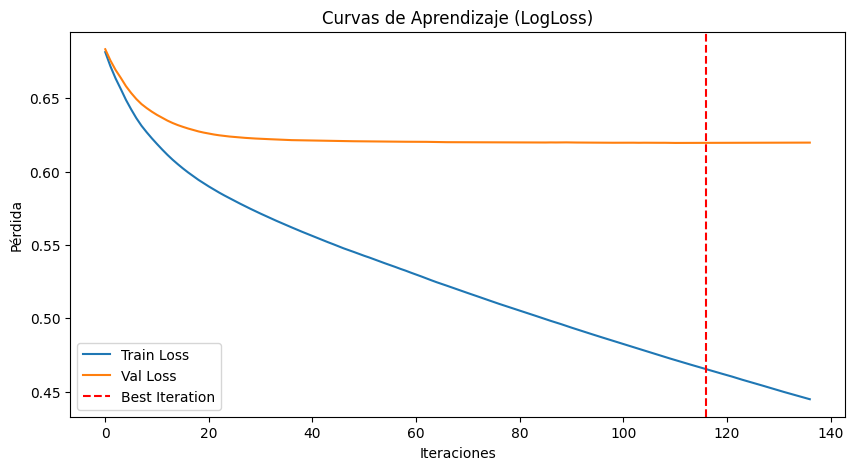

Meta-modelo guardado en /content/drive/MyDrive/Challenges_ML-DL/models/meta_model_xgb_mining_hourly.json
\n==================================================
REPORTE DEL META-MODELO (Filtro de Confianza)
              precision    recall  f1-score   support

   Fallo (0)       0.64      0.68      0.66      2115
 Acierto (1)       0.69      0.65      0.67      2320

    accuracy                           0.66      4435
   macro avg       0.66      0.67      0.66      4435
weighted avg       0.67      0.66      0.66      4435

ROC-AUC:  0.7117
F1 Macro: 0.6642


In [5]:
# @title 2. Entrenamiento y Evaluación del Meta-Modelo
if 'X_m_train' in locals():
    # Entrenar
    meta_model_xgb = train_xgboost_meta_model(X_m_train, y_m_train, X_m_test, y_m_test)

    # Curvas
    plot_learning_curves(meta_model_xgb)

    # Guardar
    meta_model_xgb.save_model(META_MODEL_PATH)
    print(f"Meta-modelo guardado en {META_MODEL_PATH}")

    # Evaluación Final
    probs = evaluate_meta_model(meta_model_xgb, X_m_test, y_m_test)
else:
    print("No hay datos para entrenar.")